# Exploratory Data Analysis


In [2]:
from pathlib import Path

# Path to your local riva_1.0 folder
DATASET_PATH = r"C:\Users\Admin\Downloads\riva_1.0"

# Outputs are shared across notebooks so the Results notebook can load them later.
OUTPUT_ROOT = Path(DATASET_PATH).parent / "riva_outputs"
BASE_DIR = Path(DATASET_PATH)
IMG_DIR = BASE_DIR / "images"
ANNOT_FILE = BASE_DIR / "annotations" / "annotations.json"
MODEL_DIR_PATH = OUTPUT_ROOT / "saved_models"
RESULTS_DIR_PATH = OUTPUT_ROOT / "results"
FIG_DIR_PATH = OUTPUT_ROOT / "figures"
for p in [MODEL_DIR_PATH, RESULTS_DIR_PATH, FIG_DIR_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("Paths configured:")
print(f"  Dataset     : {BASE_DIR}  ({'OK' if BASE_DIR.exists() else 'MISSING - check DATASET_PATH'})")
print(f"  Images      : {IMG_DIR}  ({'OK' if IMG_DIR.exists() else 'MISSING'})")
print(f"  Annotations : {ANNOT_FILE}  ({'OK' if ANNOT_FILE.exists() else 'MISSING'})")
print(f"  Models out  : {MODEL_DIR_PATH}")
print(f"  Results out : {RESULTS_DIR_PATH}")


Paths configured:
  Dataset     : C:\Users\Admin\Downloads\riva_1.0  (OK)
  Images      : C:\Users\Admin\Downloads\riva_1.0\images  (OK)
  Annotations : C:\Users\Admin\Downloads\riva_1.0\annotations\annotations.json  (OK)
  Models out  : C:\Users\Admin\Downloads\riva_outputs\saved_models
  Results out : C:\Users\Admin\Downloads\riva_outputs\results


In [3]:
import os, json, random, time, datetime, gc
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TARGET_SIZE = 224
BATCH_SIZE = 32
IMG_EXTS = ['.png', '.jpg', '.jpeg', '.bmp']

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti


In [15]:
with open(ANNOT_FILE, 'r', encoding='utf-8') as f:
    riva_annots = json.load(f)

print("RIVA annotation structure")
print(f"Total annotated images: {len(riva_annots)}")
first_img = next(iter(riva_annots))
print("Example image key:", first_img)
print("Annotator keys:", list(riva_annots[first_img].keys()))

label_image_counts = Counter()
label_keypoint_counts = Counter()
multi_label_images = 0
total_keypoints = 0

for img_name, ann_data in riva_annots.items():
    image_labels = set()

    for ann_kps in ann_data.values():
        if not isinstance(ann_kps, list):
            continue

        for kp in ann_kps:
            label = str(kp.get('keypointlabels', '')).strip().upper()

            if label and label != 'UNKNOWN':
                if label in ('ENDOCERVICAL', 'ENDOCERVICAL CELL', 'ENDOCERVICAL CELLS'):
                    label = 'ENDO'
                elif label in ('INFLAMMATION', 'INFLAMMATORY'):
                    label = 'INFL'

                image_labels.add(label)
                label_keypoint_counts[label] += 1
                total_keypoints += 1

    for label in image_labels:
        label_image_counts[label] += 1

    if len(image_labels) > 1:
        multi_label_images += 1

clinical_meanings = {
    'NILM': 'Normal cells',
    'INFL': 'Inflammation',
    'LSIL': 'Low-grade lesion',
    'HSIL': 'High-grade lesion',
    'ASCUS': 'Uncertain abnormality',
    'ASCH': 'Cannot exclude HSIL',
    'SCC': 'Invasive cancer',
    'ENDO': 'Endocervical cells'
}

total_images = len(riva_annots)

print(f"\nTOTAL IMAGES      : {total_images}")
print(f"TOTAL KEYPOINTS   : {total_keypoints}")
print(f"UNIQUE LABELS     : {len(label_image_counts)}")
print(f"MULTI-LABEL IMAGES: {multi_label_images} ({multi_label_images / total_images * 100:.1f}%)\n")

# First table: original table
print(f"{'Label':<10} {'Images':>8} {'Keypoints':>10}  Meaning")
for label in sorted(label_image_counts):
    print(
        f"{label:<10} "
        f"{label_image_counts[label]:>8,} "
        f"{label_keypoint_counts[label]:>10,}  "
        f"{clinical_meanings.get(label, 'Unknown')}"
    )

# Second table: with % of Total
print()
print(f"{'Label':>5} {'Images':>7} {'% of Total':>11} {'Keypoints':>10} {'Meaning':>22}")
for label in sorted(label_image_counts):
    percent_total = round(label_image_counts[label] / total_images * 100, 1)

    print(
        f"{label:>5} "
        f"{label_image_counts[label]:>7} "
        f"{percent_total:>11.1f} "
        f"{label_keypoint_counts[label]:>10} "
        f"{clinical_meanings.get(label, 'Unknown'):>22}"
    )

eda_stats = {
    'total_images': total_images,
    'total_keypoints': total_keypoints,
    'multi_label_images': multi_label_images,
    'label_image_counts': dict(label_image_counts),
    'label_keypoint_counts': dict(label_keypoint_counts),
}

with open(RESULTS_DIR_PATH / 'riva_eda_stats.json', 'w') as f:
    json.dump(eda_stats, f, indent=2)

print(f"\nSaved: {RESULTS_DIR_PATH / 'riva_eda_stats.json'}")

RIVA annotation structure
Total annotated images: 959
Example image key: LSIL_45_3
Annotator keys: ['annotator_2']

TOTAL IMAGES      : 959
TOTAL KEYPOINTS   : 26158
UNIQUE LABELS     : 8
MULTI-LABEL IMAGES: 718 (74.9%)

Label        Images  Keypoints  Meaning
ASCH            115        416  Cannot exclude HSIL
ASCUS           126        356  Uncertain abnormality
ENDO            105      1,270  Endocervical cells
HSIL            244      1,835  High-grade lesion
INFL            664      8,190  Inflammation
LSIL            406      3,048  Low-grade lesion
NILM            665      9,457  Normal cells
SCC             110      1,586  Invasive cancer

Label  Images  % of Total  Keypoints                Meaning
 ASCH     115        12.0        416    Cannot exclude HSIL
ASCUS     126        13.1        356  Uncertain abnormality
 ENDO     105        10.9       1270     Endocervical cells
 HSIL     244        25.4       1835      High-grade lesion
 INFL     664        69.2       8190        

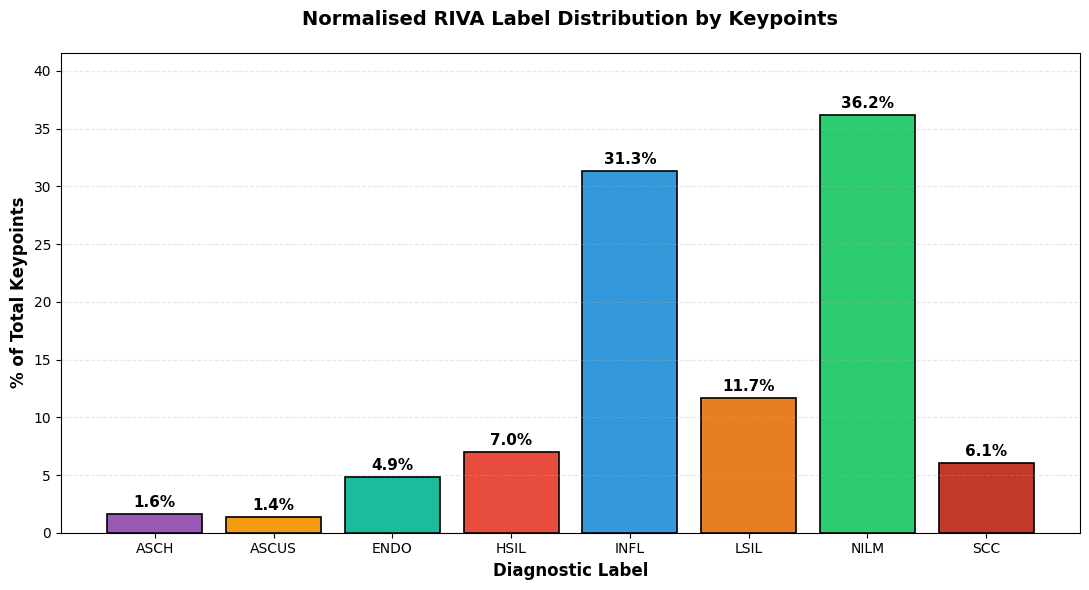

In [6]:
_kp_counts = {'ASCH':416,'ASCUS':356,'ENDO':1270,'HSIL':1835,
              'INFL':8190,'LSIL':3048,'NILM':9457,'SCC':1586}
_total = sum(_kp_counts.values())
_pcts  = {k: v/_total*100 for k,v in _kp_counts.items()}
_cols  = ['#9b59b6','#f39c12','#1abc9c','#e74c3c','#3498db','#e67e22','#2ecc71','#c0392b']

plt.figure(figsize=(11,6))
bars = plt.bar(_pcts.keys(), _pcts.values(), color=_cols, edgecolor='black', linewidth=1.2)
for bar, pct in zip(bars, _pcts.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(_pcts.values())*0.01,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylabel('% of Total Keypoints', fontsize=12, fontweight='bold')
plt.xlabel('Diagnostic Label',     fontsize=12, fontweight='bold')
plt.title('Normalised RIVA Label Distribution by Keypoints', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, max(_pcts.values())*1.15); plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('riva_label_distribution_kp.png', dpi=150, bbox_inches='tight'); plt.show()


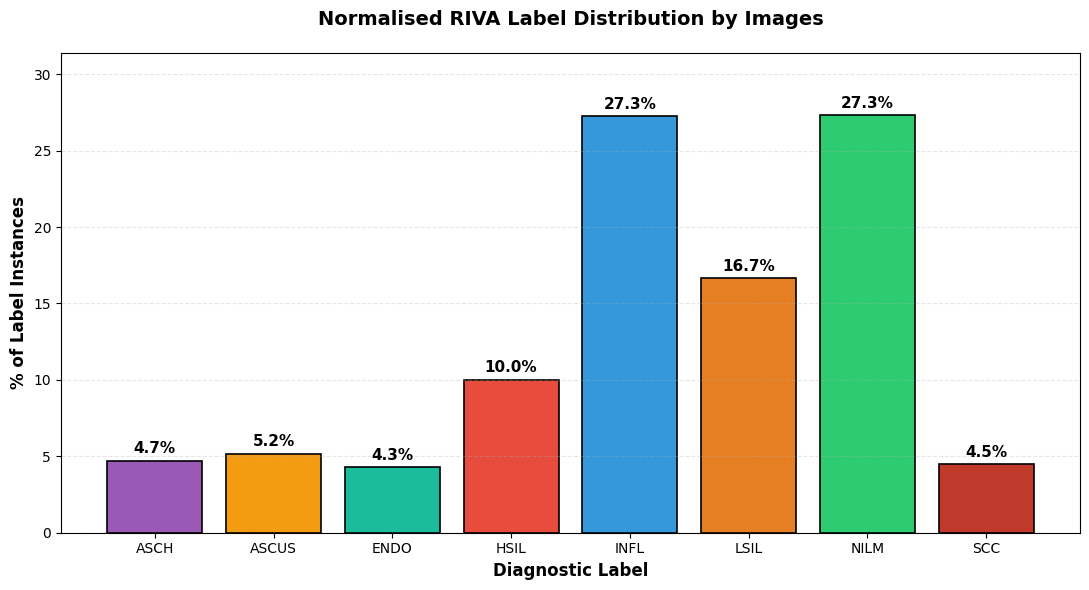

In [7]:
_img_counts = {'ASCH':115,'ASCUS':126,'ENDO':105,'HSIL':244,
               'INFL':664,'LSIL':406,'NILM':665,'SCC':110}
_ti   = sum(_img_counts.values())
_ipct = {k: v/_ti*100 for k,v in _img_counts.items()}

plt.figure(figsize=(11,6))
bars = plt.bar(_ipct.keys(), _ipct.values(), color=_cols, edgecolor='black', linewidth=1.2)
for bar, pct in zip(bars, _ipct.values()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(_ipct.values())*0.01,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylabel('% of Label Instances', fontsize=12, fontweight='bold')
plt.xlabel('Diagnostic Label',     fontsize=12, fontweight='bold')
plt.title('Normalised RIVA Label Distribution by Images', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, max(_ipct.values())*1.15); plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('riva_label_distribution_img.png', dpi=150, bbox_inches='tight'); plt.show()


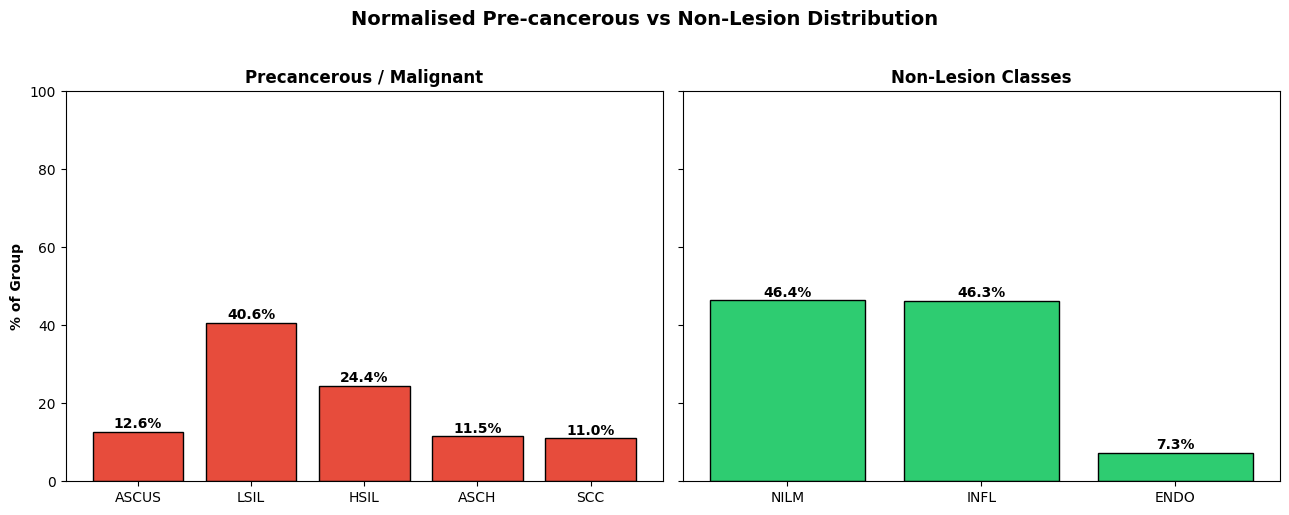

In [8]:
_pre_lbls = ['ASCUS','LSIL','HSIL','ASCH','SCC']
_non_lbls = ['NILM','INFL','ENDO']
_pre_c  = [_img_counts[l] for l in _pre_lbls]
_non_c  = [_img_counts[l] for l in _non_lbls]
_tp, _tn = sum(_pre_c), sum(_non_c)

fig, axes = plt.subplots(1, 2, figsize=(13,5), sharey=True)
axes[0].bar(_pre_lbls, [c/_tp*100 for c in _pre_c], color='#e74c3c', edgecolor='black')
axes[0].set_title('Precancerous / Malignant', fontweight='bold')
axes[0].set_ylabel('% of Group', fontweight='bold')
for i, c in enumerate(_pre_c):
    axes[0].text(i, c/_tp*100 + 1, f'{c/_tp*100:.1f}%', ha='center', fontweight='bold')
axes[1].bar(_non_lbls, [c/_tn*100 for c in _non_c], color='#2ecc71', edgecolor='black')
axes[1].set_title('Non-Lesion Classes', fontweight='bold')
for i, c in enumerate(_non_c):
    axes[1].text(i, c/_tn*100 + 1, f'{c/_tn*100:.1f}%', ha='center', fontweight='bold')
fig.suptitle('Normalised Pre-cancerous vs Non-Lesion Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.ylim(0, 100); plt.tight_layout()
plt.savefig('riva_precancerous_vs_nonlesion_norm.png', dpi=150, bbox_inches='tight'); plt.show()


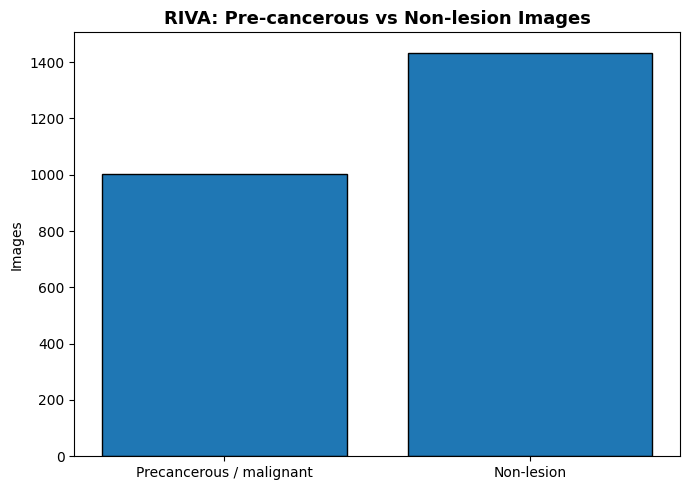

In [9]:
pre_lbls = ['ASCUS','LSIL','HSIL','ASCH','SCC']
non_lbls = ['NILM','INFL','ENDO']
pre_total = sum(label_image_counts.get(l, 0) for l in pre_lbls)
non_total = sum(label_image_counts.get(l, 0) for l in non_lbls)
plt.figure(figsize=(7, 5))
plt.bar(['Precancerous / malignant', 'Non-lesion'], [pre_total, non_total], edgecolor='black')
plt.title('RIVA: Pre-cancerous vs Non-lesion Images', fontsize=13, fontweight='bold')
plt.ylabel('Images')
plt.tight_layout()
plt.savefig(FIG_DIR_PATH / 'riva_precancerous_vs_nonlesion.png', dpi=150, bbox_inches='tight')
plt.show()


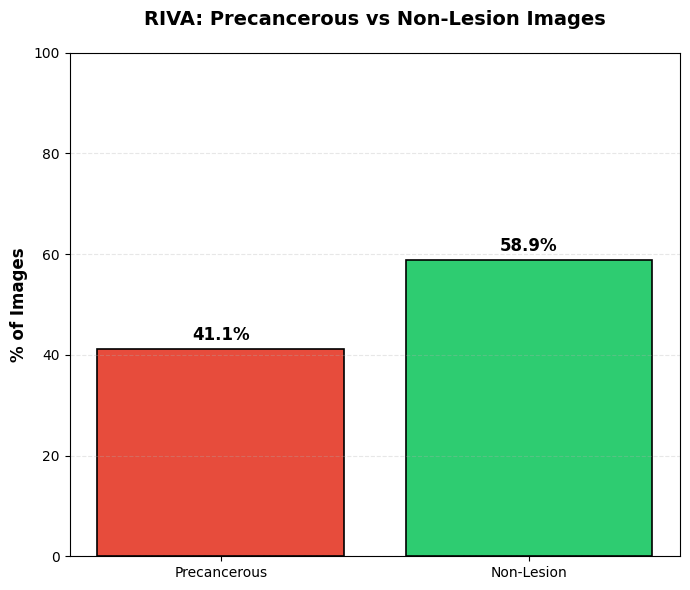

In [10]:
_tall = _tp + _tn
plt.figure(figsize=(7,6))
bars = plt.bar(['Precancerous','Non-Lesion'], [_tp/_tall*100, _tn/_tall*100],
               color=['#e74c3c','#2ecc71'], edgecolor='black', linewidth=1.2)
for bar, pct in zip(bars, [_tp/_tall*100, _tn/_tall*100]):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.ylabel('% of Images', fontsize=12, fontweight='bold')
plt.title('RIVA: Precancerous vs Non-Lesion Images', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, 100); plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('riva_precancerous_vs_nonlesion_total.png', dpi=150, bbox_inches='tight'); plt.show()


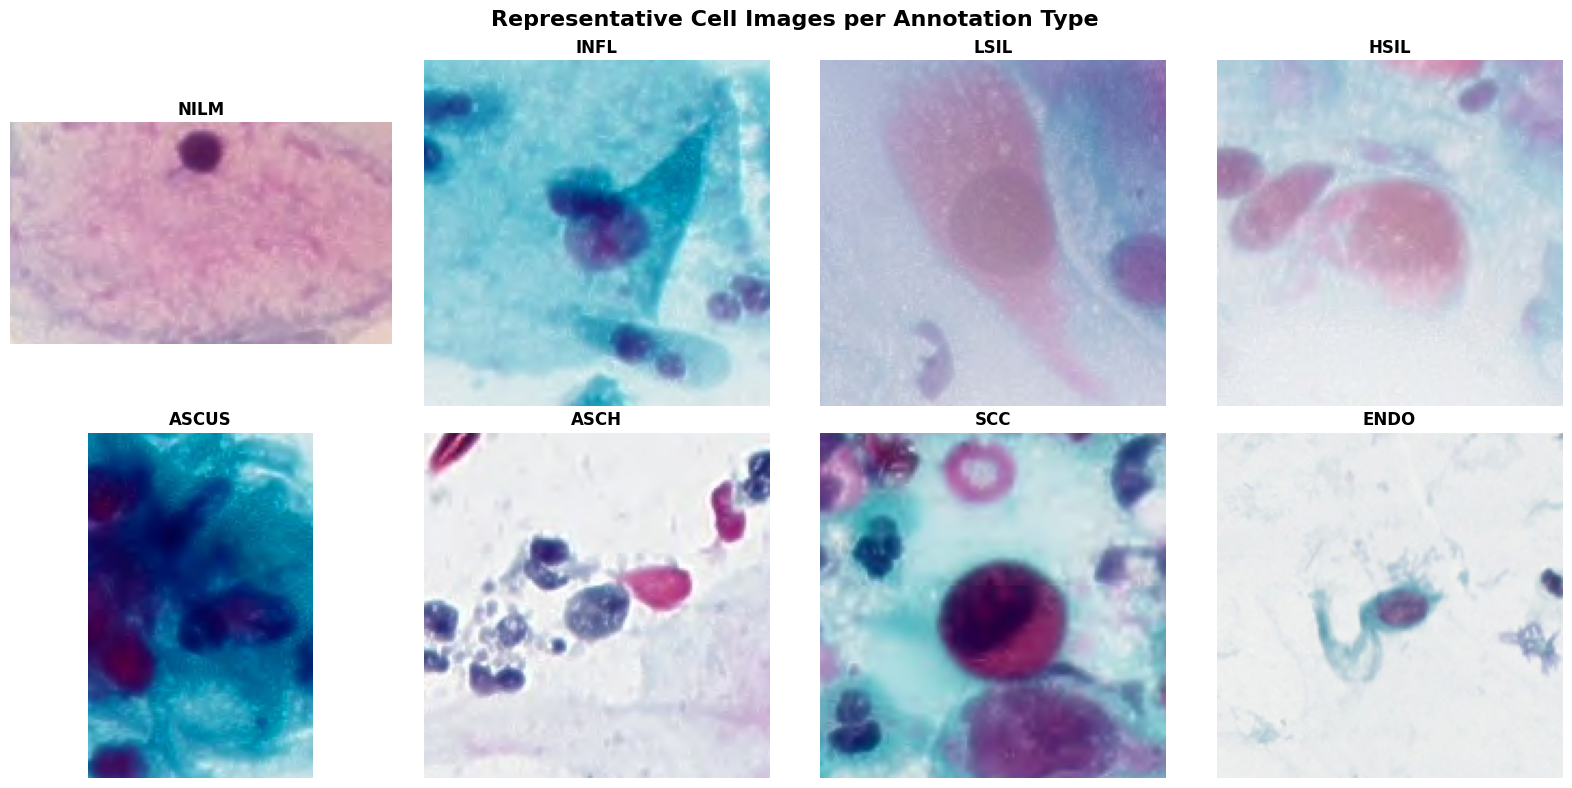

In [11]:
CELL_TYPES = ['NILM','INFL','LSIL','HSIL','ASCUS','ASCH','SCC','ENDO']
cell_examples = {}
for img_name, ann_data in riva_annots.items():
    for ann_kps in ann_data.values():
        if not isinstance(ann_kps, list):
            continue
        for kp in ann_kps:
            lbl = str(kp.get('keypointlabels', '')).strip().upper()
            if lbl in ('ENDOCERVICAL', 'ENDOCERVICAL CELL', 'ENDOCERVICAL CELLS'):
                lbl = 'ENDO'
            elif lbl in ('INFLAMMATION', 'INFLAMMATORY'):
                lbl = 'INFL'
            if lbl in CELL_TYPES and lbl not in cell_examples:
                cell_examples[lbl] = (img_name, kp)
    if len(cell_examples) == len(CELL_TYPES):
        break

plt.figure(figsize=(16, 8))
for idx, lbl in enumerate(CELL_TYPES, 1):
    if lbl not in cell_examples:
        continue
    img_name, kp = cell_examples[lbl]
    img_path = next((IMG_DIR / f"{img_name}{e}" for e in IMG_EXTS if (IMG_DIR / f"{img_name}{e}").exists()), None)
    if img_path is None:
        continue
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    x, y = int((float(kp['x'])/100)*w), int((float(kp['y'])/100)*h)
    r = 80
    crop = img.crop((max(x-r, 0), max(y-r, 0), min(x+r, w), min(y+r, h)))
    plt.subplot(2, 4, idx)
    plt.imshow(crop)
    plt.title(lbl, fontweight='bold')
    plt.axis('off')
plt.suptitle('Representative Cell Images per Annotation Type', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR_PATH / 'riva_cell_types.png', dpi=150, bbox_inches='tight')
plt.show()


Keypoint Visualisation


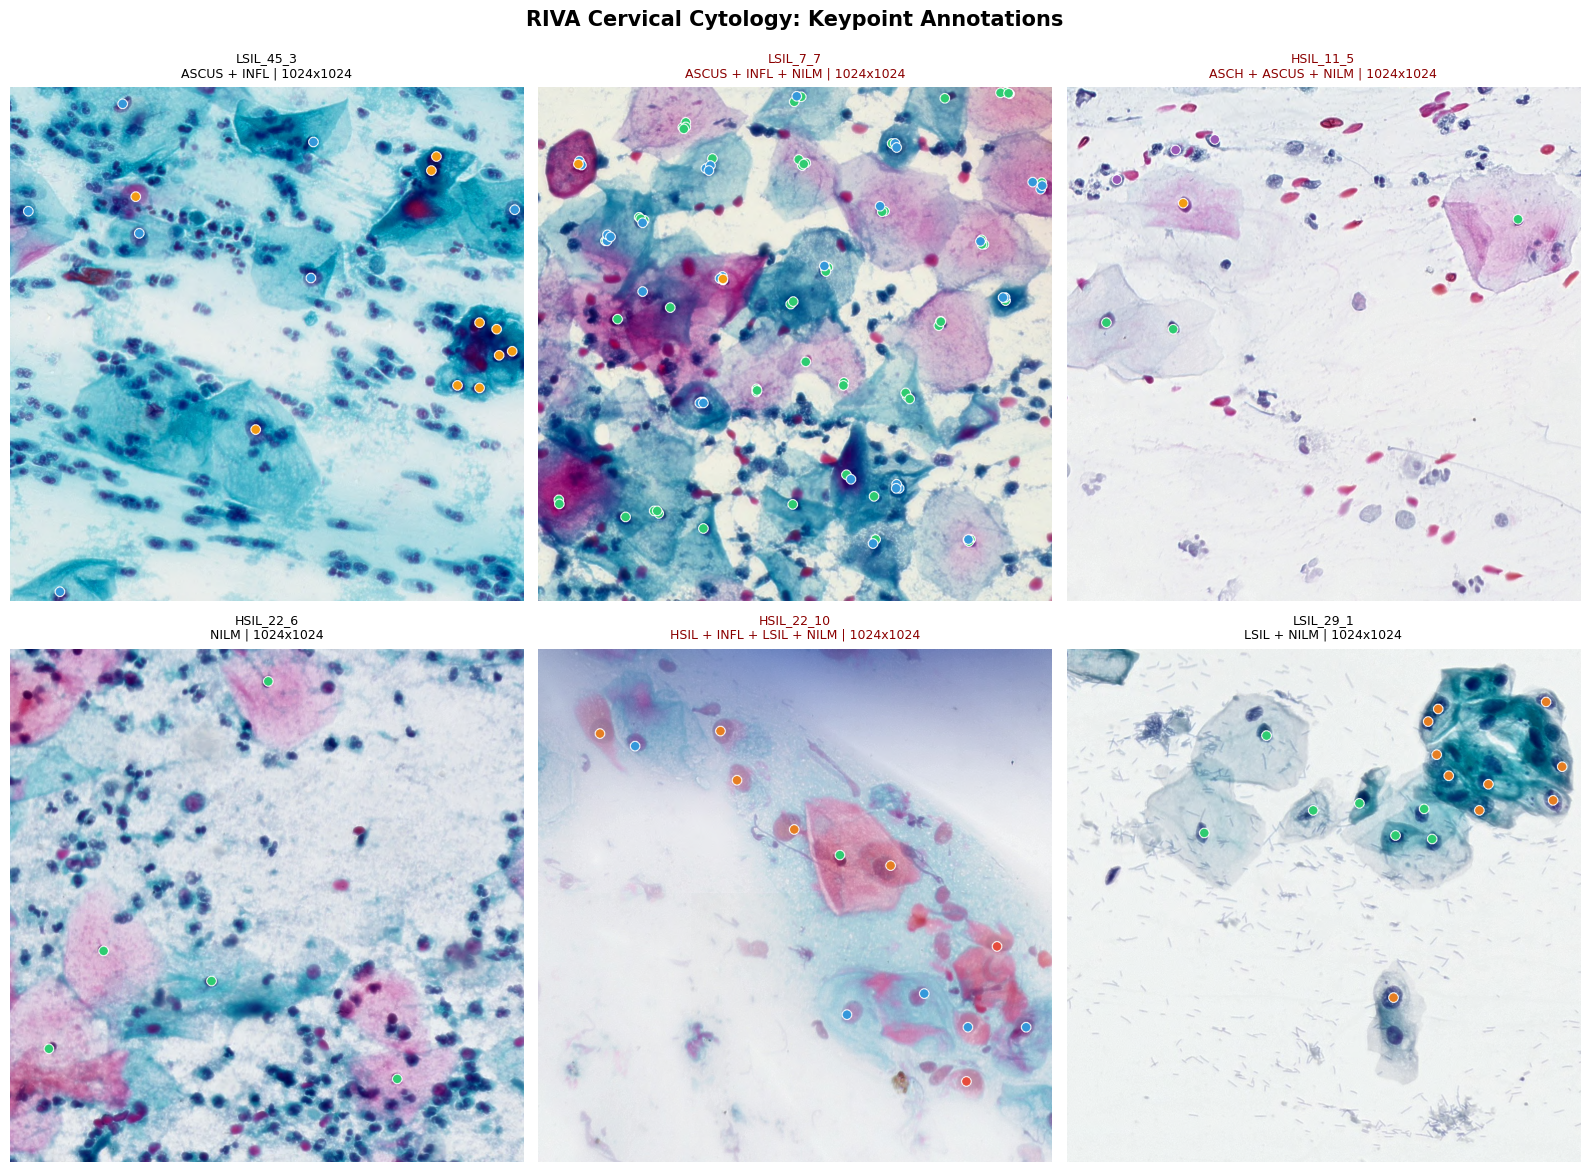

In [12]:
print("Keypoint Visualisation")
try:
    samples, seen = [], set()
    for img_name, ann_data in riva_annots.items():
        lbls = set()
        for ann_kps in ann_data.values():
            if isinstance(ann_kps, list):
                for kp in ann_kps:
                    c = kp.get("keypointlabels","").strip().upper()
                    if c and c != "UNKNOWN": lbls.add(c)
        pat = tuple(sorted(lbls))[:3]
        if pat not in seen and lbls and len(lbls) <= 4:
            samples.append((img_name, ann_data, lbls)); seen.add(pat)
            if len(samples) >= 6: break

    cat_colors = {"NILM":"#2ecc71","INFL":"#3498db","LSIL":"#e67e22","HSIL":"#e74c3c",
                  "ASCUS":"#f39c12","ASCH":"#9b59b6","SCC":"#c0392b","ENDO":"#1abc9c"}
    plt.figure(figsize=(16,12))
    for idx, (img_name, ann_data, image_lbls) in enumerate(samples, 1):
        img_path = next((IMG_DIR/f"{img_name}{e}" for e in [".bmp",".jpg",".jpeg",".png"]
                         if (IMG_DIR/f"{img_name}{e}").exists()), None)
        plt.subplot(2, 3, idx)
        if not img_path:
            plt.text(0.5,0.5,f"MISSING:\n{img_name}",ha="center",va="center",color="red")
            plt.axis("off"); continue
        img  = Image.open(img_path).convert("RGB")
        iw, ih = img.size
        draw = ImageDraw.Draw(img)
        kps_by_cat = {}
        for ann_kps in ann_data.values():
            if not isinstance(ann_kps, list): continue
            for kp in ann_kps:
                xn, yn = kp.get("x"), kp.get("y")
                c = kp.get("keypointlabels","").strip().upper()
                if xn is None or yn is None or c == "UNKNOWN": continue
                kps_by_cat.setdefault(c,[]).append(((xn/100)*iw,(yn/100)*ih))
        for c in sorted(kps_by_cat, key=lambda x: len(kps_by_cat[x]), reverse=True):
            for x, y in kps_by_cat[c]:
                draw.ellipse((x-10,y-10,x+10,y+10), outline="white",
                             fill=cat_colors.get(c,"#34495e"), width=2)
        plt.imshow(img)
        plt.title(f"{img_name}\n{' + '.join(sorted(image_lbls))} | {iw}x{ih}",
                  fontsize=9, pad=8, color="darkred" if len(image_lbls)>2 else "black")
        plt.axis("off")
    plt.suptitle("RIVA Cervical Cytology: Keypoint Annotations",
                 fontsize=15, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.savefig("riva_keypoints.png", dpi=150, bbox_inches="tight"); plt.show()
except Exception as e:
    import traceback; traceback.print_exc()


EDA complete. Figures are saved to `riva_outputs/figures` and stats to `riva_outputs/results`.
